In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats
import sys
sys.path.append("../utils")
from indicators import compute_rsi

print("Ready")

Ready


In [2]:
# Load SPY 2010-2024
df = yf.download("SPY", start="2010-01-01",
                  end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"].squeeze()
log_returns = np.log(price / price.shift(1)).dropna()

# Rebuild combined strategy from Day 21
sma50  = price.rolling(50).mean()
sma200 = price.rolling(200).mean()
sma_signal = (sma50 > sma200).astype(int).shift(1).fillna(0)

rsi2 = compute_rsi(price, period=2)
pos_list, cp = [], 0
for i in range(len(rsi2)):
    in_uptrend = price.iloc[i] > sma200.iloc[i]
    if cp == 0 and rsi2.iloc[i] < 10 and in_uptrend:
        cp = 1
    elif cp == 1 and (rsi2.iloc[i] > 90 or not in_uptrend):
        cp = 0
    pos_list.append(cp)
rsi2_signal = pd.Series(pos_list,
                         index=price.index).shift(1).fillna(0)

target_vol  = 0.10
rv          = log_returns.rolling(20).std() * np.sqrt(252)
vol_scalar  = (target_vol / rv).clip(0, 1)

position    = sma_signal.reindex(log_returns.index).fillna(0)
position    = position.where(
    rsi2_signal.reindex(log_returns.index).fillna(0)==0, 1.0)
trades      = position.diff().abs().fillna(0)
strat_ret   = (position * log_returns *
               vol_scalar.shift(1).fillna(1) -
               trades * 0.0006)

print(f"Strategy returns: {len(strat_ret)} observations")
print(f"Ann. Return: {strat_ret.mean()*252:.2%}")
print(f"Ann. Vol   : {strat_ret.std()*np.sqrt(252):.2%}")

[*********************100%***********************]  1 of 1 completed


Strategy returns: 3521 observations
Ann. Return: 6.55%
Ann. Vol   : 9.05%


In [3]:
def var_historical(returns, confidence=0.95, capital=100000):
    """Historical VaR — no distribution assumptions."""
    var_pct = np.percentile(returns, (1-confidence)*100)
    var_usd = var_pct * capital
    return var_pct, var_usd

def var_parametric(returns, confidence=0.95, capital=100000):
    """Parametric VaR — assumes normal distribution."""
    mu      = returns.mean()
    sigma   = returns.std()
    z_score = stats.norm.ppf(1-confidence)
    var_pct = mu + z_score * sigma
    var_usd = var_pct * capital
    return var_pct, var_usd

def var_montecarlo(returns, confidence=0.95,
                    capital=100000, n_sims=10000):
    """Monte Carlo VaR — simulate from fitted distribution."""
    mu    = returns.mean()
    sigma = returns.std()
    simulated = np.random.normal(mu, sigma, n_sims)
    var_pct   = np.percentile(simulated, (1-confidence)*100)
    var_usd   = var_pct * capital
    return var_pct, var_usd

def cvar(returns, confidence=0.95, capital=100000):
    """CVaR/Expected Shortfall — avg loss beyond VaR."""
    var_pct, _ = var_historical(returns, confidence)
    tail_returns = returns[returns <= var_pct]
    cvar_pct     = tail_returns.mean()
    cvar_usd     = cvar_pct * capital
    return cvar_pct, cvar_usd

# Calculate all metrics for strategy and buy & hold
capital = 100000
np.random.seed(42)

print(f"\n{'='*70}")
print(f"  VAR COMPARISON — $100,000 PORTFOLIO")
print(f"{'='*70}")
print(f"  {'Method':<20} {'95% VaR':>10} {'95% VaR $':>12} "
      f"{'99% VaR':>10} {'99% VaR $':>12}")
print(f"  {'-'*65}")

for ret, name in [(strat_ret, "Strategy"),
                   (log_returns, "Buy & Hold")]:
    print(f"\n  {name}:")
    h95, h95u = var_historical(ret, 0.95, capital)
    h99, h99u = var_historical(ret, 0.99, capital)
    p95, p95u = var_parametric(ret, 0.95, capital)
    p99, p99u = var_parametric(ret, 0.99, capital)
    m95, m95u = var_montecarlo(ret, 0.95, capital)
    m99, m99u = var_montecarlo(ret, 0.99, capital)
    c95, c95u = cvar(ret, 0.95, capital)
    c99, c99u = cvar(ret, 0.99, capital)

    print(f"  {'Historical':<20} {h95:>10.2%} {h95u:>12,.0f} "
          f"{h99:>10.2%} {h99u:>12,.0f}")
    print(f"  {'Parametric':<20} {p95:>10.2%} {p95u:>12,.0f} "
          f"{p99:>10.2%} {p99u:>12,.0f}")
    print(f"  {'Monte Carlo':<20} {m95:>10.2%} {m95u:>12,.0f} "
          f"{m99:>10.2%} {m99u:>12,.0f}")
    print(f"  {'CVaR (ES)':<20} {c95:>10.2%} {c95u:>12,.0f} "
          f"{c99:>10.2%} {c99u:>12,.0f}")

print(f"\n{'='*70}")


  VAR COMPARISON — $100,000 PORTFOLIO
  Method                  95% VaR    95% VaR $    99% VaR    99% VaR $
  -----------------------------------------------------------------

  Strategy:
  Historical               -0.96%         -963     -1.78%       -1,782
  Parametric               -0.91%         -911     -1.30%       -1,300
  Monte Carlo              -0.92%         -917     -1.33%       -1,329
  CVaR (ES)                -1.49%       -1,492     -2.33%       -2,329

  Buy & Hold:
  Historical               -1.68%       -1,681     -3.20%       -3,201
  Parametric               -1.75%       -1,753     -2.50%       -2,499
  Monte Carlo              -1.72%       -1,722     -2.53%       -2,530
  CVaR (ES)                -2.70%       -2,703     -4.56%       -4,556



In [4]:
# Define historical crisis periods
scenarios = {
    "2008 GFC"         : ("2008-09-01", "2009-03-31"),
    "2020 COVID Crash" : ("2020-02-19", "2020-03-23"),
    "2022 Bear Market" : ("2022-01-01", "2022-10-12"),
    "2018 Vol Spike"   : ("2018-01-26", "2018-02-08"),
    "2015 China Selloff": ("2015-08-17", "2015-08-25"),
}

print(f"\n{'='*72}")
print(f"  STRESS TEST RESULTS — HISTORICAL CRISIS SCENARIOS")
print(f"{'='*72}")
print(f"  {'Scenario':<22} {'Start':>10} {'End':>10} "
      f"{'Strategy':>10} {'Buy&Hold':>10} {'Protection':>10}")
print(f"  {'-'*67}")

for name, (start, end) in scenarios.items():
    # Strategy returns during crisis
    s_crisis = strat_ret.loc[start:end]
    b_crisis = log_returns.loc[start:end]

    if len(s_crisis) == 0:
        continue

    # Cumulative return during period
    s_cum = (1 + s_crisis).prod() - 1
    b_cum = (1 + b_crisis).prod() - 1

    # Protection = how much less strategy lost
    protection = s_cum - b_cum

    print(f"  {name:<22} {start:>10} {end:>10} "
          f"{s_cum:>10.2%} {b_cum:>10.2%} "
          f"{protection:>10.2%}")

print(f"{'='*72}")
print(f"\nPositive protection = strategy lost less than buy & hold")


  STRESS TEST RESULTS — HISTORICAL CRISIS SCENARIOS
  Scenario                    Start        End   Strategy   Buy&Hold Protection
  -------------------------------------------------------------------
  2020 COVID Crash       2020-02-19 2020-03-23    -11.51%    -35.44%     23.93%
  2022 Bear Market       2022-01-01 2022-10-12     -5.32%    -25.79%     20.47%
  2018 Vol Spike         2018-01-26 2018-02-08     -7.28%     -9.27%      1.99%
  2015 China Selloff     2015-08-17 2015-08-25     -7.96%    -10.74%      2.78%

Positive protection = strategy lost less than buy & hold


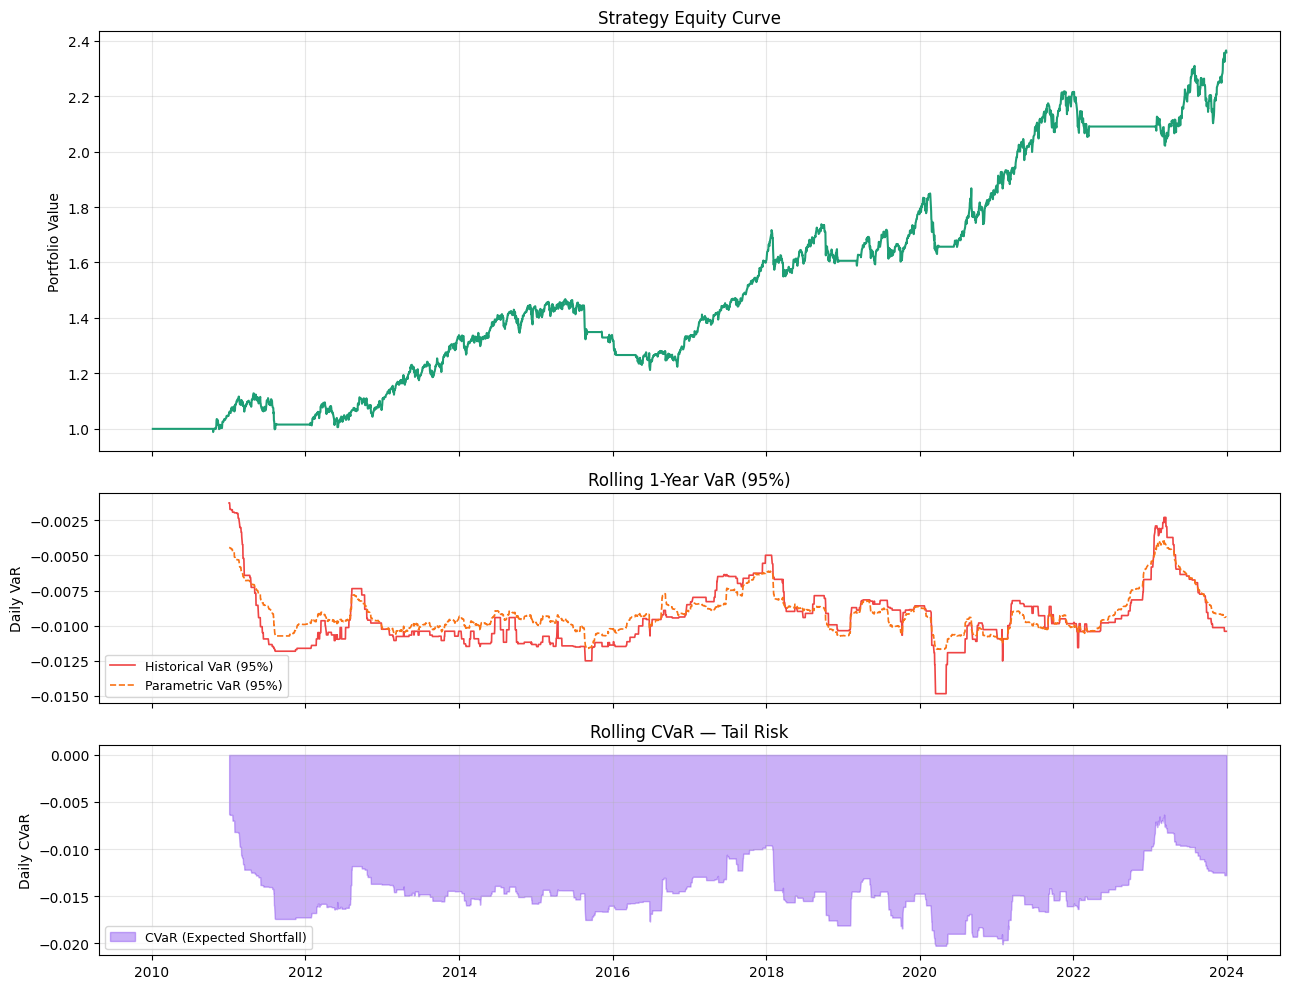


Highest risk period:
  Date     : 2020-03-16
  VaR (95%): -1.49%
  Meaning  : On this day, worst 5% of days expected loss exceeded -1.49%


In [5]:
# Rolling 252-day VaR — shows risk is not constant
window = 252

rolling_var_hist = strat_ret.rolling(window).apply(
    lambda x: np.percentile(x, 5), raw=True)
rolling_var_para = strat_ret.rolling(window).apply(
    lambda x: x.mean() + stats.norm.ppf(0.05)*x.std(),
    raw=True)
rolling_cvar = strat_ret.rolling(window).apply(
    lambda x: x[x <= np.percentile(x, 5)].mean(),
    raw=True)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 10),
    gridspec_kw={'height_ratios': [2, 1, 1]}, sharex=True)

# Strategy equity
eq = (1 + strat_ret).cumprod()
ax1.plot(eq, color='#1D9E75', lw=1.5)
ax1.set_title('Strategy Equity Curve')
ax1.set_ylabel('Portfolio Value')
ax1.grid(True, alpha=0.3)

# Rolling VaR
ax2.plot(rolling_var_hist, color='#ef4444', lw=1.2,
         label='Historical VaR (95%)')
ax2.plot(rolling_var_para, color='#f97316', lw=1.2,
         linestyle='--', label='Parametric VaR (95%)')
ax2.set_title('Rolling 1-Year VaR (95%)')
ax2.set_ylabel('Daily VaR')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Rolling CVaR
ax3.fill_between(rolling_cvar.index, rolling_cvar, 0,
                  color='#7c3aed', alpha=0.4,
                  label='CVaR (Expected Shortfall)')
ax3.set_title('Rolling CVaR — Tail Risk')
ax3.set_ylabel('Daily CVaR')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# When was risk highest?
worst_var_date = rolling_var_hist.idxmin()
worst_var_val  = rolling_var_hist.min()
print(f"\nHighest risk period:")
print(f"  Date     : {worst_var_date.date()}")
print(f"  VaR (95%): {worst_var_val:.2%}")
print(f"  Meaning  : On this day, worst 5% of days "
      f"expected loss exceeded {worst_var_val:.2%}")